In [139]:
from os import listdir
from os.path import isfile, join
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random


In [140]:
mypath="../data/dataset2-master/dataset2-master/images"
random.seed(42)

In [72]:
d_image = {}
for w in listdir(mypath):
    c_path = mypath+"/"+w
    for c in listdir(c_path):
        d_image['/'+w+'/'+c+'/'] = listdir(c_path+'/'+c)
        print(f"File {w}, class: {c} {len(listdir(c_path+'/'+c))}")

File TEST_SIMPLE, class: MONOCYTE 4
File TEST_SIMPLE, class: NEUTROPHIL 48
File TEST_SIMPLE, class: LYMPHOCYTE 6
File TEST_SIMPLE, class: EOSINOPHIL 13
File TEST, class: MONOCYTE 620
File TEST, class: NEUTROPHIL 624
File TEST, class: LYMPHOCYTE 620
File TEST, class: EOSINOPHIL 623
File TRAIN, class: MONOCYTE 2478
File TRAIN, class: NEUTROPHIL 2499
File TRAIN, class: LYMPHOCYTE 2483
File TRAIN, class: EOSINOPHIL 2497


## Observaciones visuales del dataset

### Características por clase
- **MONOCYTE**: Son medianos y su coloracion es mas  tenue, no intensa.
- **NEUTROPHIL**: Siempre tienen como 4 partes, es un poco mas intenso el color.
- **LYMPHOCYTE**: Son uno pero con color intenso.
- **EOSINOPHIL**: Tienen partes, 2 incluso hasta 4, pero estan mas dispersos, no hay un morado intenso.

### Implicaciones para el modelo
Cada uno posee una caracteristica unica, lo que llevara a una prediccion eficaz

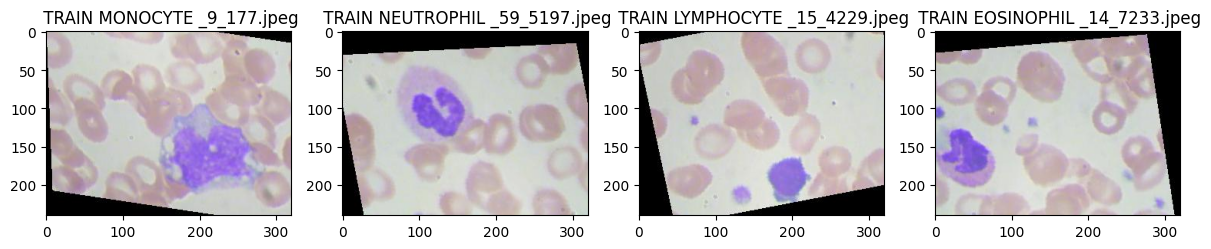

In [188]:
train_list = list(d_image.keys())[8:]
fig, axes = plt.subplots(1,4,figsize=(12,8))
for i, t in enumerate(train_list):
    c= random.choice(d_image[t])
    img = np.asarray(Image.open(mypath+t+c))
    axes[i].imshow(img)
    axes[i].set_title(t.replace("/"," ")+c)
    plt.tight_layout()

plt.savefig('../results/figures/image_analysis_train.png', dpi=150, bbox_inches='tight')
    

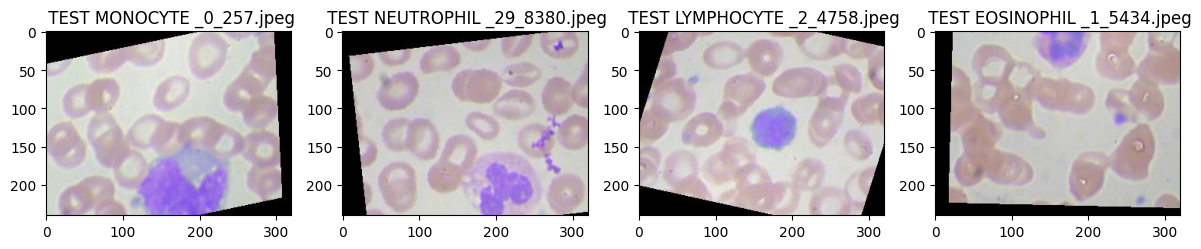

In [189]:
test_list = list(d_image.keys())[4:8]
fig, axes = plt.subplots(1,4,figsize=(12,8))
for i, t in enumerate(test_list):
    c= random.choice(d_image[t])
    img = np.asarray(Image.open(mypath+t+c))
    axes[i].imshow(img)
    axes[i].set_title(t.replace("/"," ")+c)
    plt.tight_layout()
plt.savefig('../results/figures/image_analysis_test.png', dpi=150, bbox_inches='tight')


# Analisis de tamaño de imagenes


In [126]:
size_dict = {}

for f in list(d_image.keys())[4:]:
    for im in d_image[f]:
        img = np.asarray(Image.open(mypath + f + im))
        shape_im = img.shape
        d = f.replace("/"," ").strip()
        if shape_im[0] == 240 and shape_im[1] == 320:
            size_dict[d] = size_dict.get(d, 0) + 1
        else:
            size_dict[d+" NON"] = size_dict.get(d, 0) + 1


In [127]:
size_dict

{'TEST MONOCYTE': 620,
 'TEST NEUTROPHIL': 624,
 'TEST LYMPHOCYTE': 620,
 'TEST EOSINOPHIL': 623,
 'TRAIN MONOCYTE': 2478,
 'TRAIN NEUTROPHIL': 2499,
 'TRAIN LYMPHOCYTE': 2483,
 'TRAIN EOSINOPHIL': 2497}

## Analisis de histogramas RGB por clase

A partir de los histogramas de los canales **R (Red)**, **G (Green)** y **B (Blue)** para las clases Monocyte, Neutrophil, Lymphocyte y Eosinophil, se observan las siguientes caracteristicas:

- Las distribuciones de intensidad de pixeles son relativamente similares entre clases, especialmente en valores altos de intensidad.
- En los canales **R** y **B**, la clase **Eosinophil** presenta una menor concentracion de pixeles aproximadamente en el rango **200–225**, mostrando una ligera diferencia respecto a las demas clases.
- En el canal **G**, la clase **Lymphocyte** muestra una mayor diferenciacion, particularmente en el rango aproximado de **175–200**, donde la distribucion se separa ligeramente del resto.
- Aunque existen pequeñas variaciones entre clases, los histogramas presentan un alto grado de superposicion.

El analisis de histogramas RGB sugiere que el color por si solo no es suficiente para distinguir claramente las clases celulares.

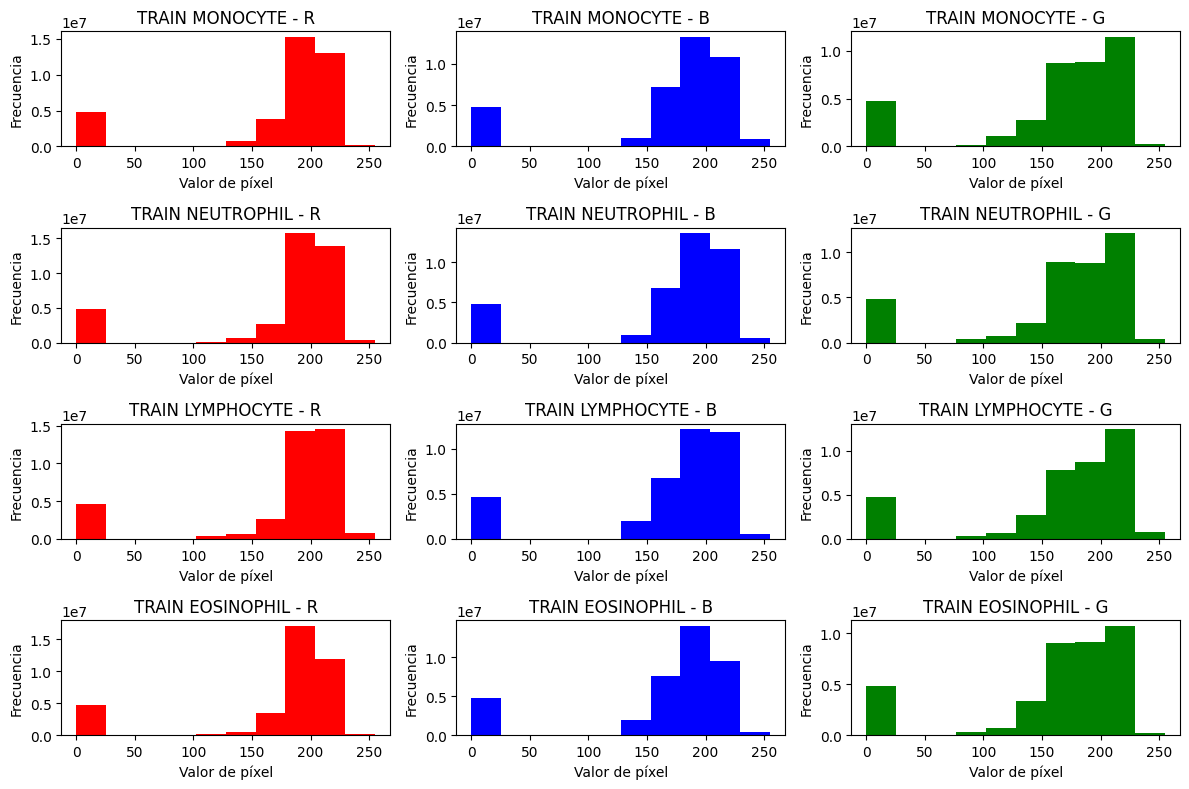

In [190]:
fig, axes = plt.subplots(4,3, figsize=(12,8))

for i,f in enumerate(list(d_image.keys())[8:]):
    red = np.array([])
    green = np.array([])
    blue = np.array([])
    sample_im = random.sample(d_image[f], k = int(len(d_image[f])*0.2))

    for s in sample_im:
        img = Image.open(mypath+f+s)
        r, g, b = img.split()
        red =   np.concatenate((red,np.asarray(r).flatten()),axis=0)
        green = np.concatenate((green,np.asarray(g).flatten()),axis=0)
        blue =  np.concatenate((blue,np.asarray(b).flatten()),axis=0)

    axes[i][0].set_title(f"{f.replace('/',' ').strip()} - R")
    axes[i][0].set_xlabel("Valor de píxel")
    axes[i][0].set_ylabel("Frecuencia")
    axes[i][0].hist(red, color='red')
    axes[i][1].set_title(f"{f.replace('/',' ').strip()} - B")
    axes[i][1].set_xlabel("Valor de píxel")
    axes[i][1].set_ylabel("Frecuencia")
    axes[i][1].hist(blue, color='blue')
    axes[i][2].set_title(f"{f.replace('/',' ').strip()} - G")
    axes[i][2].set_xlabel("Valor de píxel")
    axes[i][2].set_ylabel("Frecuencia")
    axes[i][2].hist(green, color='green')
    plt.tight_layout()
    
plt.savefig('../results/figures/image_analysis_RGB.png', dpi=150, bbox_inches='tight')


# Comprobar imagenes corruptas

In [187]:
for f in list(d_image.keys())[4:]:
    for im in d_image[f]:
        try:
            Image.open(mypath + f + im)
        except:
            print(f"File corrupted: {mypath + f + im}")

No hay imagenes corruptas